# Notebook for setting up and prcoessing the RHINO calibration Gibbs Sampler

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sampler.reader import ObservationReader, ReflectionReader

## Set up observation and reflections

In [2]:
observation = ObservationReader('simulated_data/sim_data.hdf5')
print(np.unique(observation.states_array))

reflection_dict = {'antenna':'simulated_data/antenna_gamma_src.s2p',
                   'heated_load':"simulated_data/heated_load_gamma_src.s2p",
                   'internal_load':'simulated_data/internal_load_gamma_src.s2p',
                   'long_open':'simulated_data/long_open_gamma_src.s2p',
                   'long_short':'simulated_data/long_short_gamma_src.s2p',
                   'open':'simulated_data/open_gamma_src.s2p',
                   'short':'simulated_data/short_gamma_src.s2p',
                   'receiver':'simulated_data/gamma_rec.s2p'}

reflections = ReflectionReader(component_dict=reflection_dict,
                               output_frequencies=observation.freqs,
                               polynomial_interp=True,
                               polynomial_fitting_order=10)

['antenna' 'heated_load' 'internal_load' 'long_open' 'long_short' 'open'
 'short']


/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampl

In [3]:
from sampler.linear_basis import BasisConstructor

## Set up basis functions

In [4]:
gains_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=5,
                               basis_function='polynomial',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=(observation.freqs[-1] - observation.freqs[0])*4,
                               zero_time=True)

unc_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=5,
                               n_freq_modes=5,
                               basis_function='polynomial',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=(observation.freqs[-1] - observation.freqs[0])*4,
                               zero_time=True)

cos_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=5,
                               n_freq_modes=5,
                               basis_function='polynomial',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=(observation.freqs[-1] - observation.freqs[0])*4,
                               zero_time=True)

sin_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=5,
                               n_freq_modes=5,
                               basis_function='polynomial',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=(observation.freqs[-1] - observation.freqs[0])*4,
                               zero_time=True)

rx_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=5,
                               n_freq_modes=5,
                               basis_function='polynomial',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=(observation.freqs[-1] - observation.freqs[0])*4,
                               zero_time=True)

ambient_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=(observation.freqs[-1] - observation.freqs[0])*4,
                               zero_time=True)

heated_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=(observation.freqs[-1] - observation.freqs[0])*4,
                               zero_time=True)

antenna_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=5,
                               basis_function='polynomial',
                               time_norm=(observation.times[-1] - observation.times[0])*4,
                               frequency_norm=(observation.freqs[-1] - observation.freqs[0])*4,
                               zero_time=True)

## Construct Operators

In [ ]:
from sampler.operator_setup import generate_noise_wave_transfer_matrix
from sampler.operator_setup import generate_non_smooth_source_matrix, generate_smooth_source_matrix, generate_noise_wave_transfer_matrix
# Noise Wave Operator
X_noise_wave, nw_index_dict = generate_noise_wave_transfer_matrix(observation,
                                                               reflections,
                                                               unc_basis,
                                                               cos_basis,
                                                               sin_basis,
                                                               rx_basis)
print(nw_index_dict)
print(X_noise_wave.shape)


## Construct Antenna Operator

In [ ]:
X_antenna = generate_smooth_source_matrix(observation,
                                          reflections,
                                          source_basis=antenna_basis,
                                          source_label='antenna')

print(X_antenna.shape)

(1474560, 5)


### Combine Noisewave and Antenna Operators

In [ ]:


X_ant_noisewave = np.concatenate((X_antenna, X_noise_wave), axis=1)


## Construct Calibration Source Operator

In [ ]:
print(np.unique(observation.switch_states))

['antenna' 'heated_load' 'internal_load' 'long_open' 'long_short' 'open'
 'short']


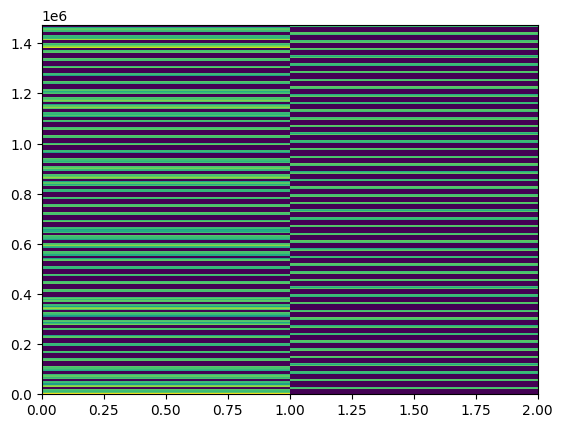

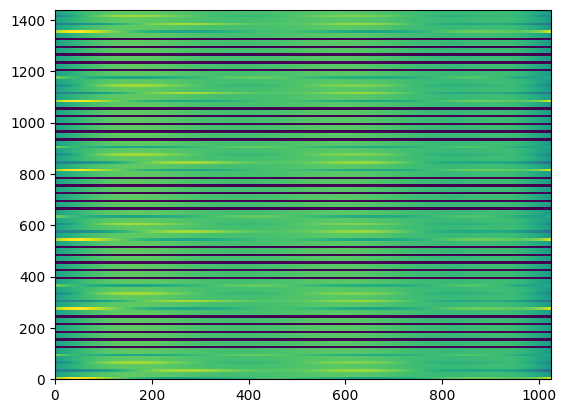

In [ ]:
X_ambient = generate_smooth_source_matrix(observation, reflections,
                                          source_basis=ambient_basis,
                                          source_label=['internal_load', 'long_open',
                                                        'long_short', 'open', 'short'])
X_heated = generate_smooth_source_matrix(observation, reflections,
                                         source_basis=heated_basis,
                                         source_label='heated_load')

X_calibrator = np.concatenate((X_ambient, X_heated), axis=1)
plt.pcolormesh(X_calibrator)
plt.show()
cont = X_calibrator @ np.ones_like(X_calibrator[0])
cont = np.reshape(cont, shape=observation.data_waterfall.shape)
plt.pcolormesh(cont)
plt.show()

### Construct Cal Source Priors

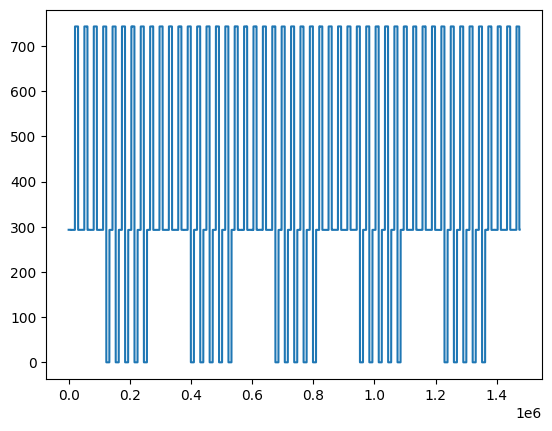

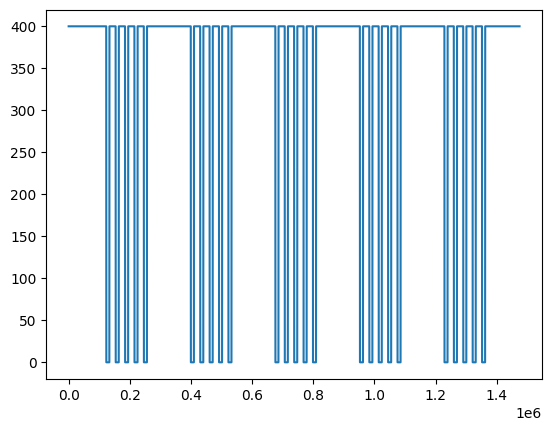

In [ ]:
from sampler.priors import setup_probe_cal_priors
cal_source_priors, cal_source_prior_inv_cov = setup_probe_cal_priors(observation,
                                           source_temp_dict={'heated':'heated_load',
                                                             'ambient':['internal_load',
                                                                        'open',
                                                                        'short',
                                                                        'long_open',
                                                                        'long_short']},
                                                                        temp_std=0.05)

plt.plot(cal_source_priors)
plt.show()
plt.plot(cal_source_prior_inv_cov)
plt.show()

In [ ]:
### Attempt a Weiner solution fit

from sampler.gibbs_sample import construct_gcr_lhs, construct_gcr_rhs, solve_gcr

cal_source_lhs = construct_gcr_lhs(linear_operator=X_calibrator,
                                   inv_data_cov=cal_source_prior_inv_cov,
                                   inv_prior_cov=cal_source_prior_inv_cov)
cal_source_rhs = construct_gcr_rhs(linear_operator=X_calibrator,
                                   data=cal_source_priors,
                                   inv_data_cov=cal_source_prior_inv_cov,
                                   omega_data=np.zeros_like(observation.data_waterfall.flatten()),
                                   priors=cal_source_priors,
                                   inv_prior_cov=cal_source_prior_inv_cov,
                                   weiner_solution=True)

init_calibrator_solution = solve_gcr(cal_source_lhs, cal_source_rhs)

# ambient_amps, heated_amps = init_calibrator_solution[:4], init_calibrator_solution[4:]
# print(ambient_amps)
# print(heated_amps)

# reconstructed_ambient = ambient_basis.basis_matrix @ ambient_amps
# reconstructed_heated = ambient_basis.basis_matrix @ heated_amps

# plt.pcolormesh(np.reshape(reconstructed_ambient, shape=observation.data_waterfall.shape))
# plt.colorbar()
# plt.show()

# plt.pcolormesh(np.reshape(reconstructed_heated, shape=observation.data_waterfall.shape))
# plt.colorbar()
# plt.show()

## Gain Operator

In [ ]:
U_gain = gains_basis.basis_matrix
print(U_gain.shape)
# plt.pcolormesh(U_gain)
# plt.show()

(1474560, 5)


# Set up Gibbs Sampler

In [ ]:
from sampler.gibbs_sample import sample_loop

In [ ]:
param_dict = sample_loop(data=observation.data_waterfall.flatten(),
                         N=observation.Nw.flatten(),
                         U_gain=U_gain,
                         X_ant_nw=X_ant_noisewave,
                         X_cal_src=X_calibrator,
                         init_gain_amps=np.ones_like(U_gain[0]),
                         init_cal_src_amps=init_calibrator_solution,
                         init_ant_nw_amps=np.ones_like(X_ant_noisewave[0]),
                         cal_src_priors=cal_source_priors,
                         inv_cal_src_prior_cov=cal_source_prior_inv_cov, n_iter=50,
                         verbose=False)

Gibbs Sample - 0 / 50


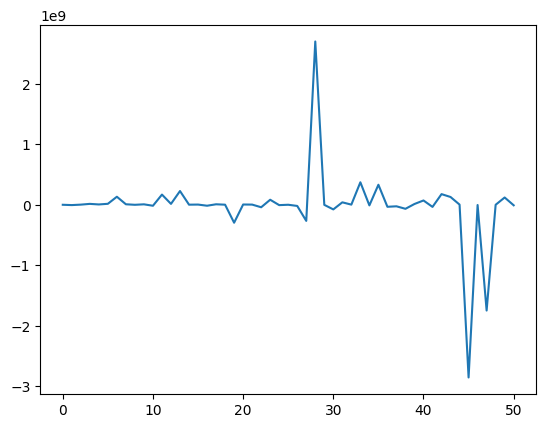

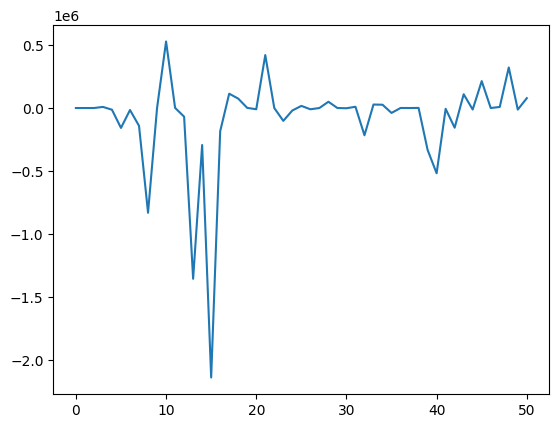

In [ ]:
plt.plot(param_dict['all_p_gain'][:,-1])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, -1])
plt.show()

In [ ]:
param_dict = sample_loop(data=observation.data_waterfall.flatten(),
                         N=observation.Nw.flatten(),
                         U_gain=U_gain,
                         X_ant_nw=X_ant_noisewave,
                         X_cal_src=X_calibrator,
                         init_gain_amps=np.median(param_dict['all_p_gain'], axis=0),
                         init_cal_src_amps=init_calibrator_solution,
                         init_ant_nw_amps=np.median(param_dict['all_p_ant_nw'], axis=0),
                         cal_src_priors=cal_source_priors,
                         inv_cal_src_prior_cov=cal_source_prior_inv_cov, n_iter=50,
                         verbose=False)

Gibbs Sample - 0 / 50


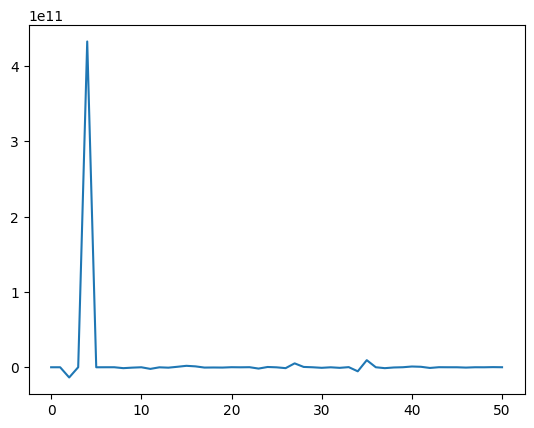

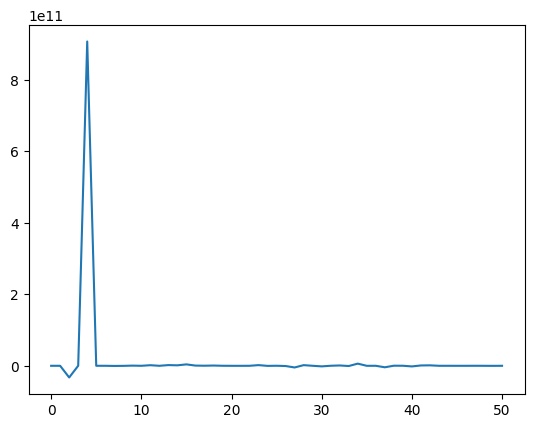

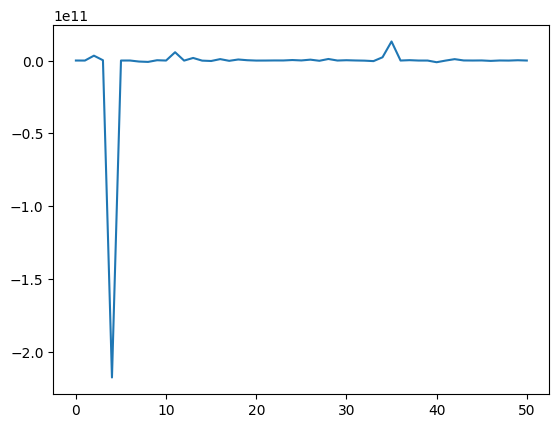

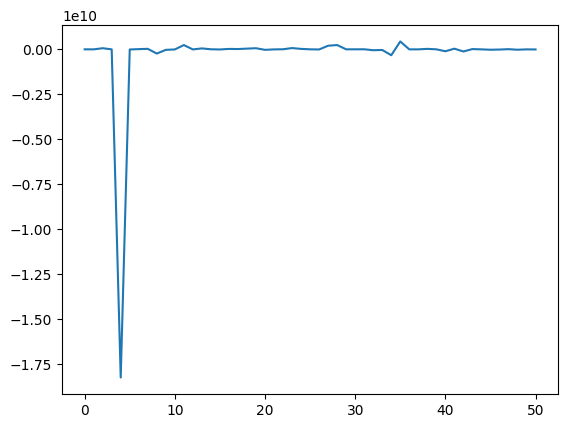

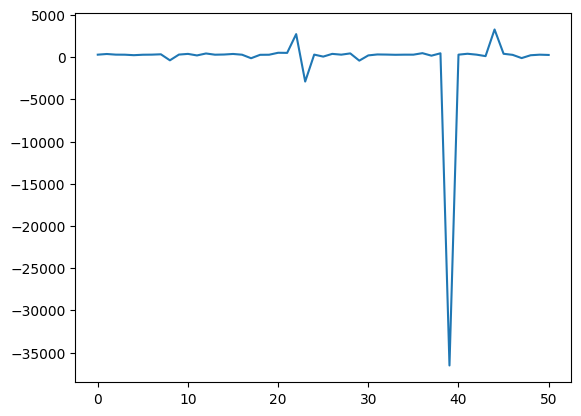

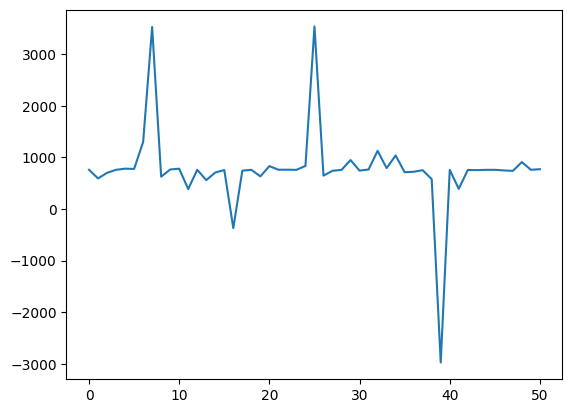

760.2063169162612


In [ ]:
# plt.plot(param_dict['all_p_gain'][:,0])
# plt.show()
# plt.plot(param_dict['all_p_gain'][:,2])
# plt.show()
# plt.plot(param_dict['all_p_gain'][:,4])
# plt.show()
# plt.plot(param_dict['all_p_gain'][:,-1])
# plt.show()
# plt.plot(param_dict['all_p_cal_src'][:, 3])
# plt.show()
# plt.plot(param_dict['all_p_cal_src'][:, -1])
# plt.show()


print(np.median(param_dict['all_p_cal_src'][:, -1]))

[-5.04931216e+03 -1.81324647e+03  5.73072233e+03  1.00000000e+00
 -3.53488066e+04  2.82042373e+04  1.50895649e+04 -3.09864308e+04
 -2.83646118e+04  2.48178626e+04  3.05292357e+04 -2.19880938e+04
 -3.06735121e+03 -4.61735294e+04  1.13282247e+03 -1.62806805e+04
 -3.23034690e+03 -1.19539831e+04 -2.56007101e+04  4.65963589e+03
 -8.86032561e+02 -2.40302718e+03  1.29957034e+04 -3.77223958e+04
 -1.00837535e+05 -2.37792530e+04 -1.19957380e+04 -4.78151359e+04
 -3.30290564e+04  2.45066001e+04  3.50047636e+04 -2.73690891e+03
  4.26879108e+01  1.27814847e+04 -2.55755308e+04  1.83605278e+04
 -3.24900090e+03 -9.77212045e+03 -1.21686199e+03  8.62293023e+03
  1.02461886e+03 -4.29360502e+04 -3.98145403e+04  7.20388881e+04
  1.41953749e+04 -5.99791832e+03 -2.96426310e+04  1.14966147e+04]


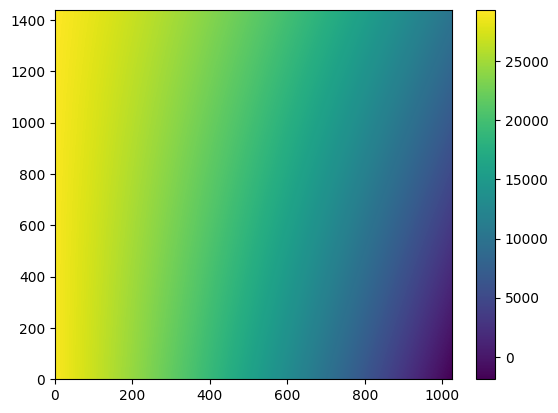

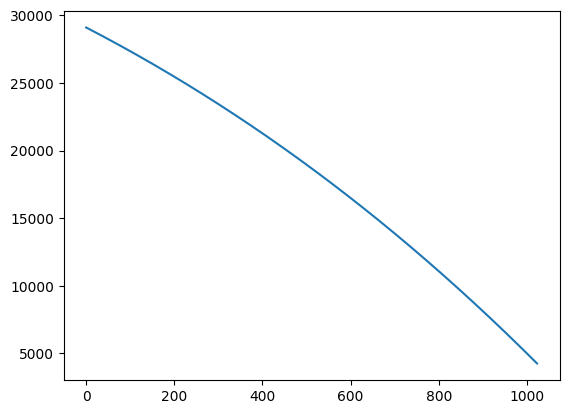

In [ ]:
# Recovered Antenna

median_p_ant_nw = np.median(param_dict['all_p_ant_nw'], axis=0)
median_p_ant = median_p_ant_nw[:len(X_antenna[0])]
median_p_nw = median_p_ant_nw[len(X_antenna[0]):]
print(median_p_nw)


reconstructed_antenna = antenna_basis.basis_matrix @ median_p_ant
reconstructed_antenna = np.reshape(reconstructed_antenna, shape=observation.data_waterfall.shape)

plt.pcolormesh(reconstructed_antenna)
plt.colorbar()
plt.show()

plt.plot(reconstructed_antenna.mean(axis=0))
plt.show()

[-3.50771114e+06  1.58221746e+07 -3.36586051e+06 -7.84636053e+06
  1.00000000e+00 -9.99051103e+06  5.92071667e+06 -4.95306745e+06
 -4.04156410e+06  9.43110481e+06 -5.46724480e+06  1.77070730e+06]


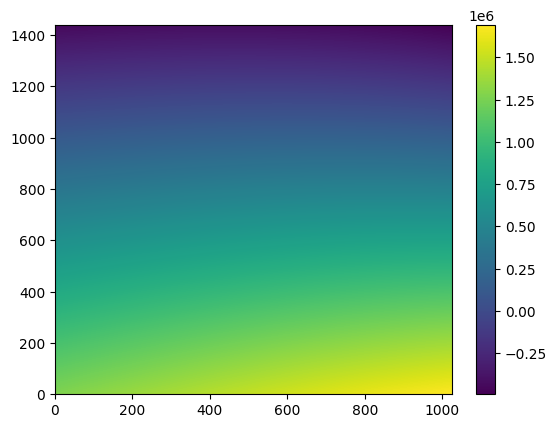

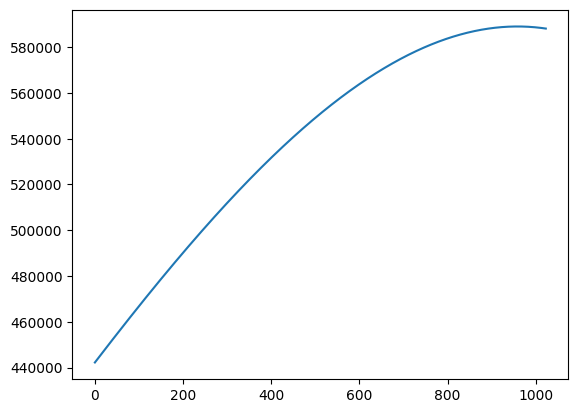

In [ ]:
median_gains = np.median(param_dict['all_p_gain'], axis=0)

print(median_gains)

reconstructed_gains = gains_basis.basis_matrix @ median_gains

reconstructed_gains = np.reshape(reconstructed_gains, shape=observation.data_waterfall.shape)

plt.pcolormesh(reconstructed_gains)
plt.colorbar()
plt.show()

plt.plot(np.mean(reconstructed_gains, axis=0))
plt.show()

In [ ]:
a = np.ones(shape=(5,))
b = np.zeros_like(a)

c = np.vstack((a,b))
print(c.shape)
print(c[0])

(2, 5)
[1. 1. 1. 1. 1.]


In [ ]:
gains_operator[0]

dummy_gain_amps = np.zeros_like(gains_operator[0])

print(dummy_gain_amps)


print(gains_operator @ dummy_gain_amps)

NameError: name 'gains_operator' is not defined

In [ ]:
import h5py
sim_filepath = 'simulated_data/sim_data.hdf5_sim'
with h5py.File(sim_filepath) as f:
    t_unc_sim = f['t_unc'][()]
    t_sin_sim = f['t_sin'][()]
    t_cos_sim = f['t_cos'][()]